# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [20]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

/var/folders/m8/wg_l2pxd3k1fwzsjpscfdpxh0000gn/T/ipykernel_77766/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

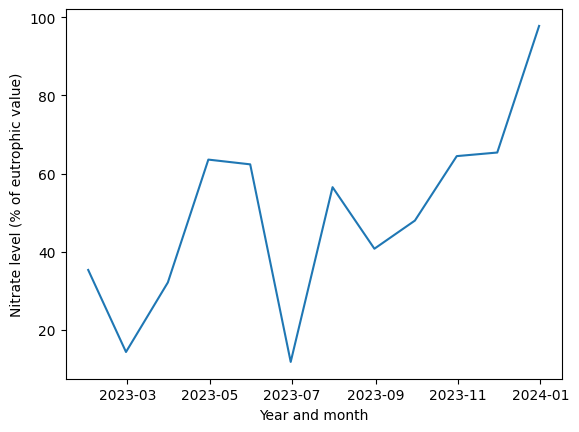

In [21]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

## Advantages of the area plot
An area plot can be useful because it shows the overall combined magnitude of nitrate and phosphate levels over time. The shaded areas make it easy to visualize the contribution of each variable to the total level in the water sample. It also helps viewers quickly see general trends and changes over time in a visually impactful way.

/var/folders/m8/wg_l2pxd3k1fwzsjpscfdpxh0000gn/T/ipykernel_77766/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

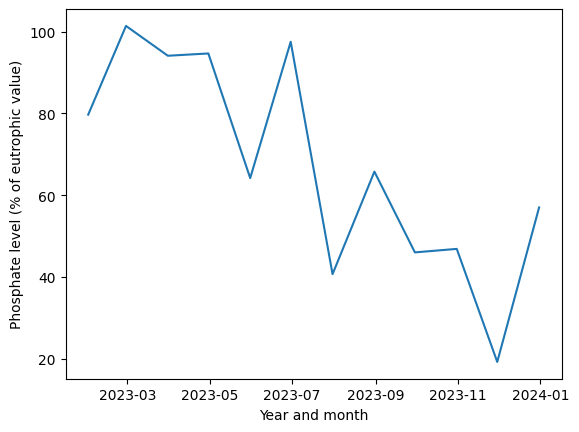

In [22]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

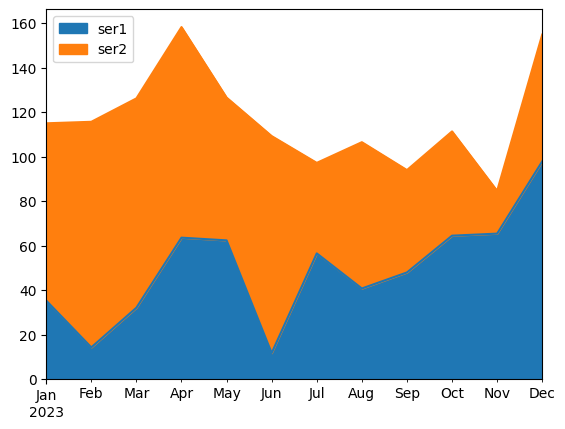

In [23]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

## Disadvantages of the area plot

However, an area plot is not ideal when the goal is to compare nitrate and phosphate levels individually. Because the areas are stacked and shaded, it can be difficult to clearly distinguish the exact values and trends for each variable. One variable may visually dominate the graph and hide variations in the other. This can make interpretation less precise compared to simpler graph types.

## How the graphs could be improved

The presentation could be improved by using line graphs when the goal is to compare nitrate and phosphate levels individually. Line graphs allow the viewer to clearly see the trend and fluctuations of each variable over time. In addition, the graphs should include clear titles, labeled axes, and a legend so that the variables are easy to interpret. Improving the formatting of the time axis and ensuring consistent scales would also make the visualization easier to understand.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

## Week 6 – Bivariate Analysis

For this analysis, I continued using the cleaned cancer dataset prepared in Homework 4.  
Since the dataset was already cleaned and validated, I used the cleaned dataframe to explore relationships between variables.

In this section, I examine how **Age varies across Gender and Race/Color groups** using grouped summaries and visualizations such as boxplots and histograms.

In [24]:
df_core = pd.read_csv("cleaned_cancer_data.csv")

## Formality check

So, I'll be running some formality check to make sure that my data has been copied over is clean!!

In [25]:
df_core[['Age', 'Gender', 'Raca.Color']].isna().sum()

Age           0
Gender        0
Raca.Color    0
dtype: int64

In [26]:
df_core[['Age', 'Gender', 'Raca.Color']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1702960 entries, 0 to 1702959
Data columns (total 3 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Age         float64
 1   Gender      object 
 2   Raca.Color  object 
dtypes: float64(1), object(2)
memory usage: 39.0+ MB


In [27]:
df_core[['Age', 'Gender', 'Raca.Color']].head()

,Age,Gender,Raca.Color
0,30.0,MASCULINO,BRANCO
1,53.0,FEMININO,UNKNOWN
2,51.0,FEMININO,PARDA
3,73.0,FEMININO,UNKNOWN
4,71.0,MASCULINO,BRANCO


In [28]:
df_bi = df_core[['Age', 'Gender', 'Raca.Color']].copy()

print(df_bi.shape)
df_bi.head()

(1702960, 3)


,Age,Gender,Raca.Color
0,30.0,MASCULINO,BRANCO
1,53.0,FEMININO,UNKNOWN
2,51.0,FEMININO,PARDA
3,73.0,FEMININO,UNKNOWN
4,71.0,MASCULINO,BRANCO


In [29]:
df_bi.groupby('Gender')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
FEMININO,930952.0,58.226085,17.281131,0.0,47.0,60.0,71.0,117.0
IGNORADO,171.0,62.807018,12.273508,20.0,61.5,62.0,68.0,93.0
MASCULINO,771837.0,62.399880,15.876913,0.0,55.0,64.0,73.0,118.0


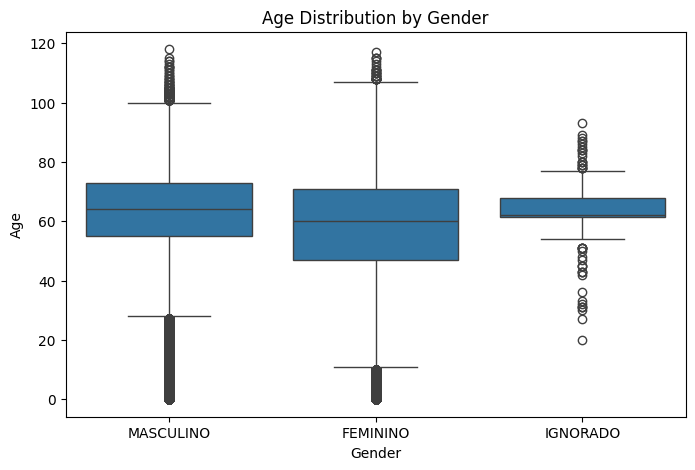

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_bi, x='Gender', y='Age')
plt.title('Age Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

In [31]:
df_bi.groupby('Raca.Color')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Raca.Color,,,,,,,,
AMARELA,24705.0,62.038009,16.284938,0.0,53.00,63.0,74.00,103.0
BRANCO,606351.0,62.843261,16.690188,0.0,53.00,65.0,75.00,118.0
INDÍGENA,1354.0,55.428360,20.593836,0.0,43.25,58.0,70.75,107.0
PARDA,294703.0,58.236608,17.353792,0.0,48.00,60.0,71.00,117.0
PRETA,49619.0,60.116709,16.244630,0.0,50.00,62.0,72.00,111.0
UNKNOWN,726228.0,58.550151,16.370670,0.0,49.00,62.0,69.00,115.0


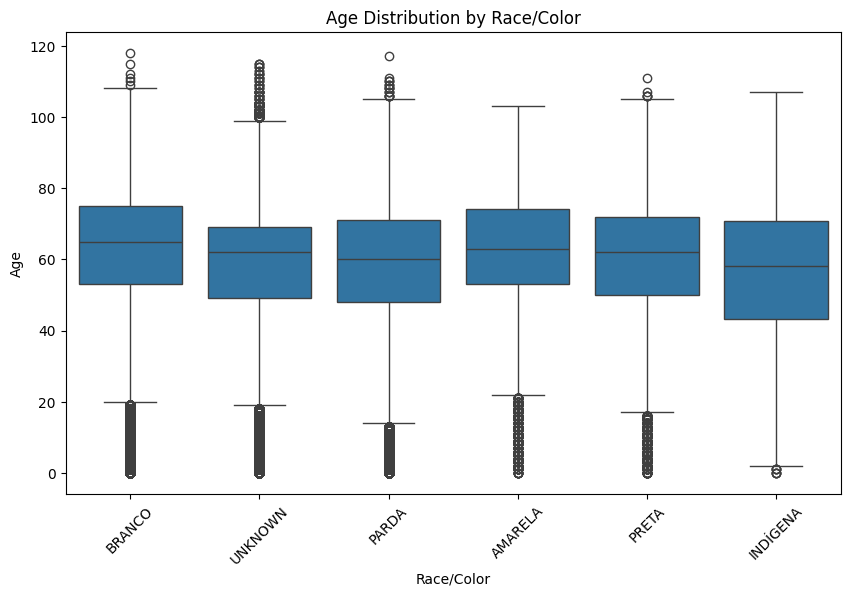

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_bi, x='Raca.Color', y='Age')
plt.title('Age Distribution by Race/Color')
plt.xlabel('Race/Color')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()

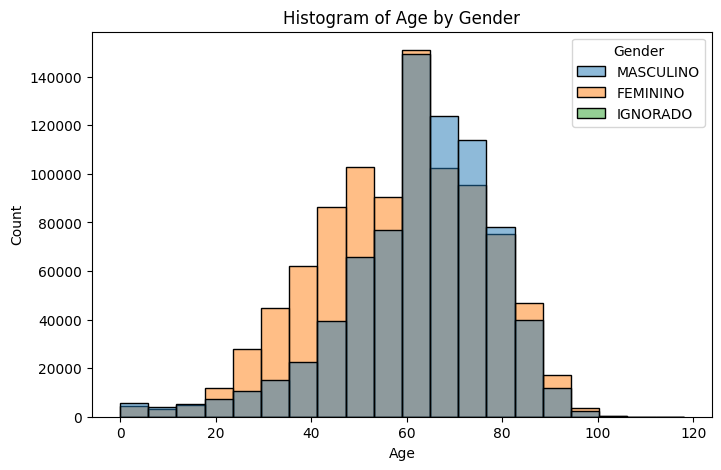

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_bi, x='Age', hue='Gender', bins=20, multiple='layer')
plt.title('Histogram of Age by Gender')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Correlation Analysis

To further explore relationships between numerical variables, I examined correlations between Age and Year of Diagnosis. This helps determine whether there is any relationship between the age of patients and the time period when diagnoses occurred.

In [34]:
df_core[['Age','year']].corr()

,Age,year
Age,1.000000,0.033829
year,0.033829,1.000000


In [40]:
sample = df_core.sample(n=3000, random_state=42)

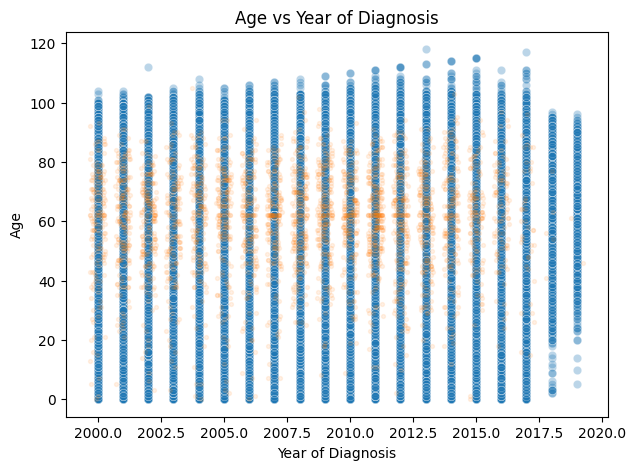

In [41]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_core, x='year', y='Age', alpha=0.3)
jitter = np.random.uniform(-0.3, 0.3, size=len(sample))
plt.scatter(sample['year'] + jitter, sample['Age'], alpha=0.1, s=8)
plt.title("Age vs Year of Diagnosis")
plt.xlabel("Year of Diagnosis")
plt.ylabel("Age")
plt.show()

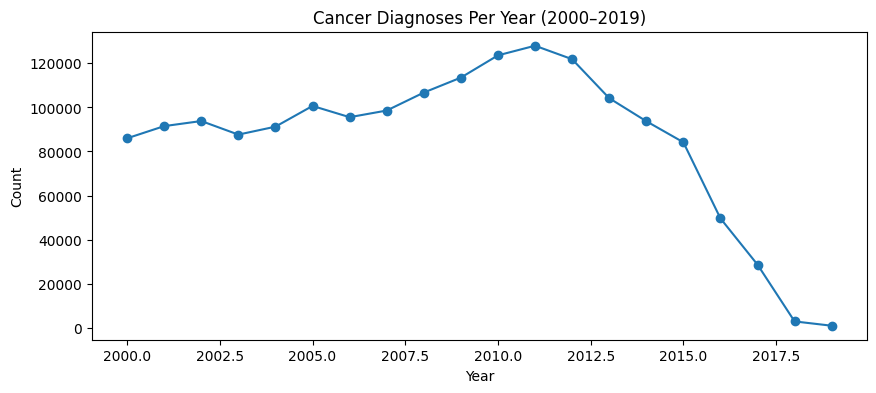

In [42]:
yearly = df_core.groupby('year').size().reset_index(name='count')
yearly = yearly[(yearly['year'] >= 2000) & (yearly['year'] <= 2019)]
plt.figure(figsize=(10, 4))
plt.plot(yearly['year'], yearly['count'], marker='o')
plt.title('Cancer Diagnoses Per Year (2000–2019)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

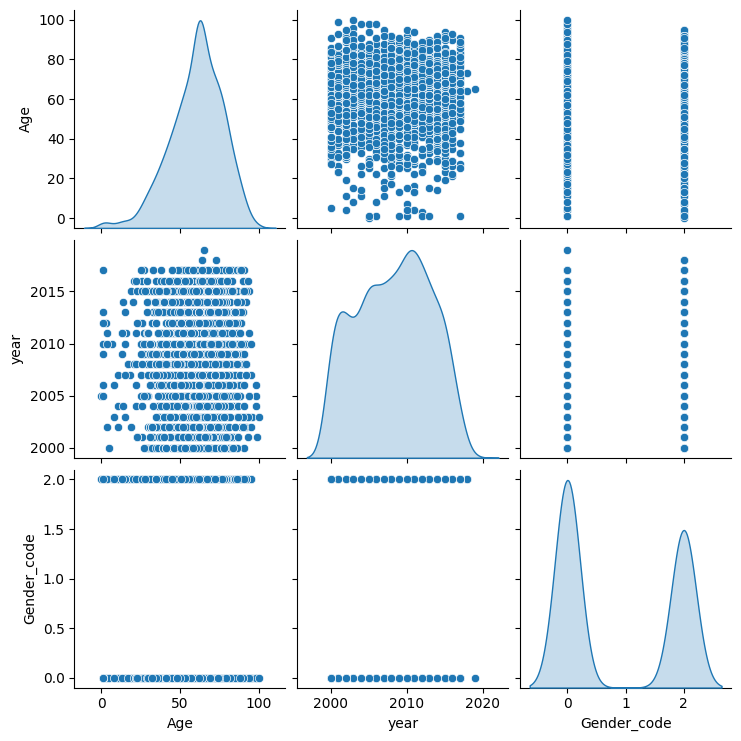

In [39]:
pair_df = df_core[['Age','year']].copy()
pair_df['Gender_code'] = df_core['Gender'].astype('category').cat.codes
sns.pairplot(pair_df.dropna().sample(2000), diag_kind='kde')

## Conclusions

In this analysis, I explored relationships between Age and demographic variables such as Gender and RaceColor using the cleaned cancer dataset prepared in Homework 4. Grouped summary statistics and boxplots were used to compare the distribution of ages across gender categories. The results suggest that the age distributions for males and females are broadly similar, with median ages clustered around the early to mid-60s. The boxplots also show the presence of several outliers at both very young and very old ages, which is expected in large medical datasets where extreme cases may occur.

When examining Age by RaceColor, the distributions appear relatively similar across categories. Most groups have comparable median ages and interquartile ranges, although some categories have slightly wider spreads. Some race categories also contain fewer observations, which may affect the stability of the summary statistics and visual comparisons.

The histogram grouped by gender provides another perspective on the age distribution. Both genders follow a roughly similar distribution pattern, with the highest concentration of observations occurring in middle to older ages. This is consistent with general medical patterns where many cancer diagnoses occur later in life.

To explore relationships between numerical variables, I calculated the correlation between Age and Year of Diagnosis. The correlation coefficient was very close to zero, indicating little to no linear relationship between patient age and the year of diagnosis. The scatterplot confirms this result, showing that ages remain distributed across similar ranges across years.

I also examined the number of diagnoses per year using a line graph. The results show fluctuations in the number of recorded diagnoses over time, with a peak around the early 2010s followed by a sharp decline in later years. This decline may reflect incomplete reporting or data availability for the most recent years rather than a true decrease in diagnoses, so these values should be interpreted cautiously.

Overall, the dataset appears usable for exploratory analysis after cleaning. The variables show consistent patterns and reasonable distributions. However, potential confounding variables such as cancer type, geographic region, healthcare access, or changes in reporting practices may influence the observed patterns and were not examined in this analysis.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

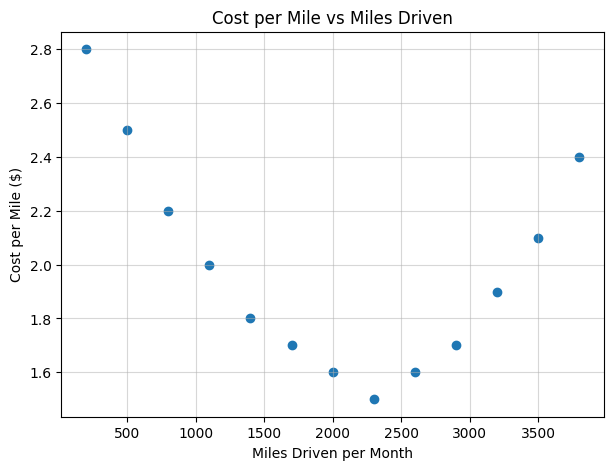

In [45]:
data = {
    "Miles Driven":[200,500,800,1100,1400,1700,2000,2300,2600,2900,3200,3500,3800],
    "Cost per Mile":[2.8,2.5,2.2,2.0,1.8,1.7,1.6,1.5,1.6,1.7,1.9,2.1,2.4]
}

df = pd.DataFrame(data)

plt.figure(figsize=(7,5))
plt.scatter(df["Miles Driven"], df["Cost per Mile"])

plt.title("Cost per Mile vs Miles Driven")
plt.xlabel("Miles Driven per Month")
plt.ylabel("Cost per Mile ($)")
plt.grid(alpha=0.5)

plt.show()

I reproduced a scatterplot inspired by the examples from Storytelling With Data. Scatterplots are useful for visualizing relationships between two numerical variables because they allow patterns or correlations to become visible. In this example, the chart shows the relationship between miles driven and cost per mile. The visualization suggests that cost per mile decreases as miles driven increase up to a point, and then begins to increase again at very high mileage levels. This type of visualization helps identify patterns and potential relationships in the data.